Inspired by: Milán Simity - Data Science weekend @Lakitelek

For one of the most widely known use cases of the newtonian approximation check out [this](https://www.youtube.com/watch?v=p8u_k2LIZyo) video about the ingenious fast inverse square root algorithm of Quake 3

### [Newton-Raphson](https://en.wikipedia.org/wiki/Newton's_method) root finding method



Iteratively approximates the roots of real-valued function

$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

We can get the an approximation of the derivative of a function with the central difference formula:

$$
f'(x) \approx \frac{f(x + h) - f(x - h)}{2h}
$$

(Think about why computing the derivative analytically might not be possible in numerical analysis especially with machine learning / neural networks)

In [ ]:
from typing import Callable, List

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# define function we want to finds the roots of
def f(x):
    return x**2 - 4


# central difference formula
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)


def plot_newton_step(
    x: np.ndarray,
    y: np.ndarray,
    x_current: float,
    step_history: List[float],
    f: Callable[[float], float],
    iteration: int,
) -> float:
    """
    Plot a single step of the Newton-Raphson method
    """
    plt.figure(figsize=(7, 7))

    # function
    plt.plot(x, y, "b-", label="f(x) = x² - 4")

    # axes
    plt.axhline(y=0, color="k", linewidth=0.8)
    plt.axvline(x=0, color="k", linewidth=0.8)

    # one step of Newton's method
    f_prime = numerical_derivative(f, x_current)
    x_new = x_current - f(x_current) / f_prime

    tangent_x = np.linspace(x_current - 2, x_current + 2, 100)
    tangent_y = f(x_current) + f_prime * (tangent_x - x_current)
    plt.plot(tangent_x, tangent_y, "--", label=f"Tangent at step {iteration}")

    plt.plot(x_current, f(x_current), "ro")

    # plot prev
    for prev_x in step_history[:-1]:
        plt.plot(prev_x, f(prev_x), "ro", alpha=0.3)

    plt.grid(True)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

    return x_new

In [51]:
# Initial setup
x = np.linspace(-5, 5, 1000)
y = f(x)
x_current = 4.0
step_history = [x_current]

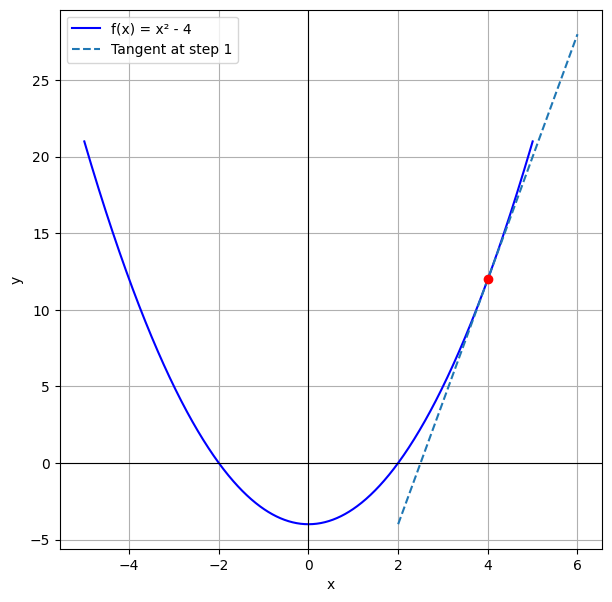

In [52]:
# Step 1
x_current = plot_newton_step(x, y, x_current, step_history, f, 1)
step_history.append(x_current)

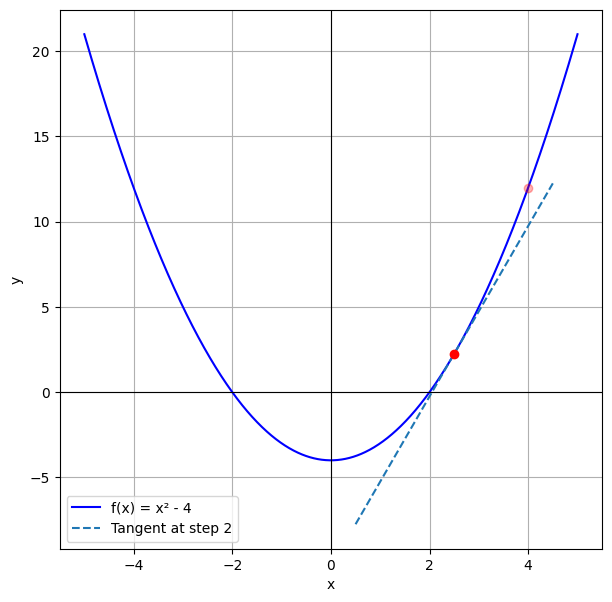

In [53]:
# Step 2
x_current = plot_newton_step(x, y, x_current, step_history, f, 2)
step_history.append(x_current)

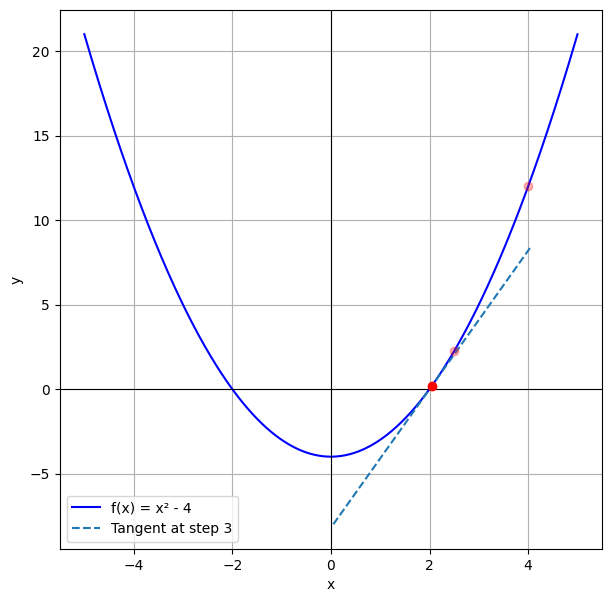

In [54]:
# Step 3
x_current = plot_newton_step(x, y, x_current, step_history, f, 3)
step_history.append(x_current)

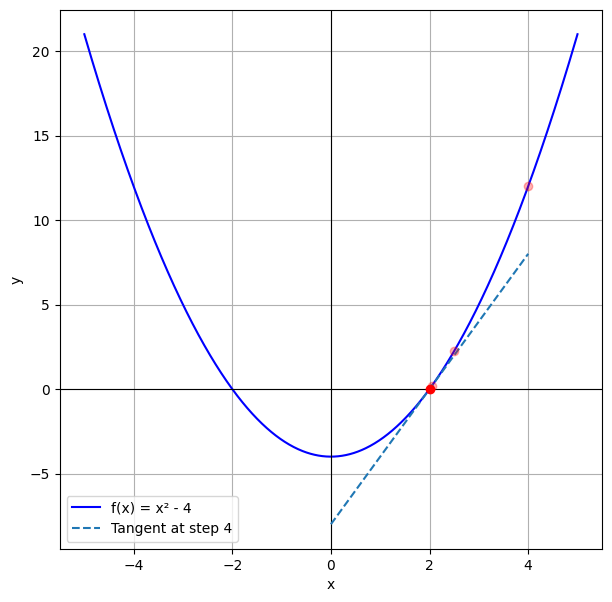

In [55]:
# Step 4
x_current = plot_newton_step(x, y, x_current, step_history, f, 4)
step_history.append(x_current)

In [56]:
print("Convergence steps:")
for i, x in enumerate(step_history):
    print(f"Step {i}: x = {x:.10f}, f(x) = {f(x):.10f}")

Convergence steps:
Step 0: x = 4.0000000000, f(x) = 12.0000000000
Step 1: x = 2.5000000000, f(x) = 2.2499999998
Step 2: x = 2.0500000000, f(x) = 0.2025000000
Step 3: x = 2.0006097561, f(x) = 0.0024393962
Step 4: x = 2.0000000929, f(x) = 0.0000003717


### Finding minima of a function with the Newton-Raphson mehtod

Using the Newton-Raphson method with one simple change, use higher order derivatives.

Since, a function has a local minima where it's derivative has a root

$$
x_{n+1} = x_n - \frac{f'(x_n)}{f''(x_n)}
$$


In [61]:
def f(x):
    return x**4 - 4 * x**2 + 2 * x


def numerical_second_derivative(f, x, h=1e-5):
    return (f(x + h) - 2 * f(x) + f(x - h)) / (h**2)

In [65]:
def plot_newton_step_minima(x, y, x_current, step_history, f, iteration):
    """
    Plot a single step of the Newton-Raphson method for finding minima
    """
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    # original function
    plt.plot(x, y, "b-", label="f(x) = x⁴ - 4x² + 2x")
    plt.axhline(y=0, color="k", linewidth=0.8)
    plt.axvline(x=0, color="k", linewidth=0.8)

    # current and previous points
    plt.plot(x_current, f(x_current), "ro")
    for prev_x in step_history[:-1]:
        plt.plot(prev_x, f(prev_x), "ro", alpha=0.3)

    plt.grid(True)
    plt.legend()
    plt.ylabel("y")

    # Plot derivative
    plt.subplot(2, 1, 2)
    derivative_y = [numerical_derivative(f, xi) for xi in x]
    plt.plot(x, derivative_y, "g-", label="f'(x)")
    plt.axhline(y=0, color="k", linewidth=0.8)
    plt.axvline(x=0, color="k", linewidth=0.8)

    # Calculate derivatives for Newton step
    f_prime = numerical_derivative(f, x_current)
    f_double_prime = numerical_second_derivative(f, x_current)
    x_new = x_current - f_prime / f_double_prime

    # Plot tangent line on derivative plot
    tangent_x = np.linspace(x_current - 1, x_current + 1, 100)
    tangent_y = f_prime + f_double_prime * (tangent_x - x_current)
    plt.plot(tangent_x, tangent_y, "--", label=f"Tangent at step {iteration}")

    # Plot current and previous points on derivative
    plt.plot(x_current, f_prime, "ro")
    for prev_x in step_history[:-1]:
        prev_derivative = numerical_derivative(f, prev_x)
        plt.plot(prev_x, prev_derivative, "ro", alpha=0.3)

    plt.grid(True)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")

    plt.tight_layout()
    plt.show()

    return x_new

In [66]:
# Initial setup
x = np.linspace(-3, 3, 1000)
y = f(x)
x_current = 2.5  # Starting point
step_history = [x_current]

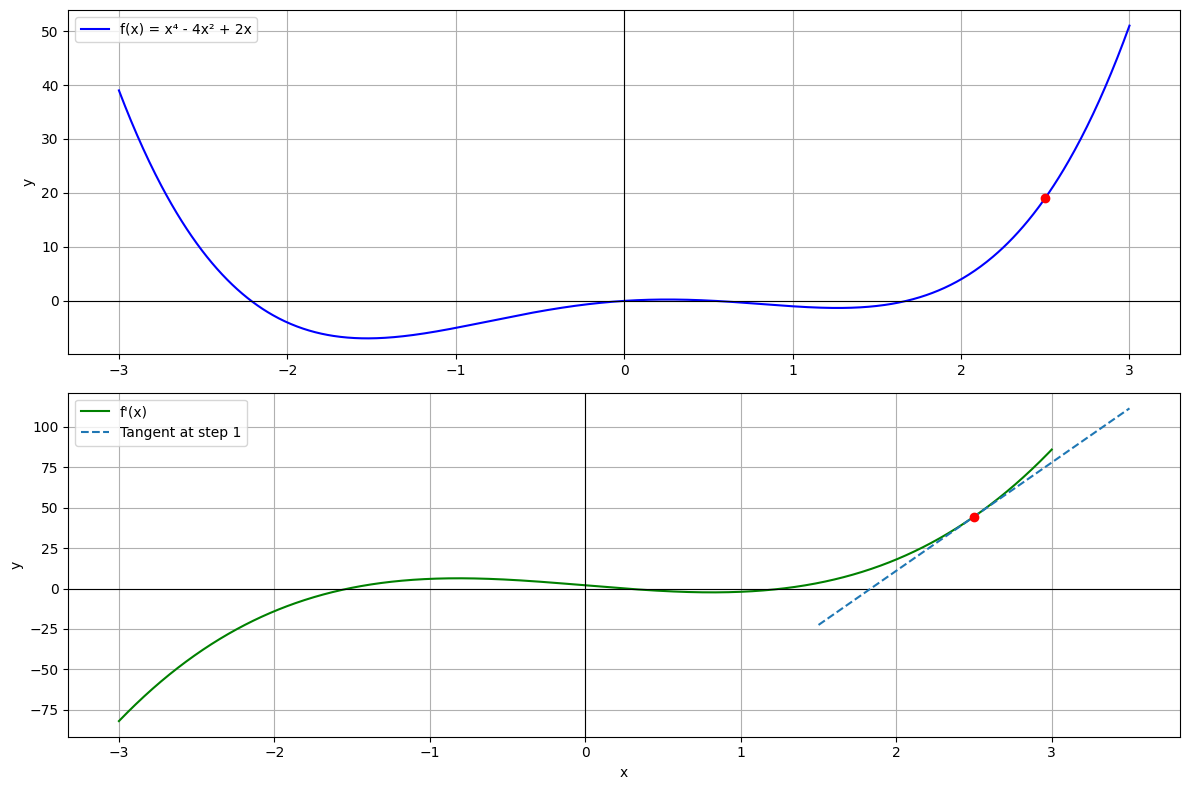

In [67]:
# Step 1
x_current = plot_newton_step_minima(x, y, x_current, step_history, f, 1)
step_history.append(x_current)

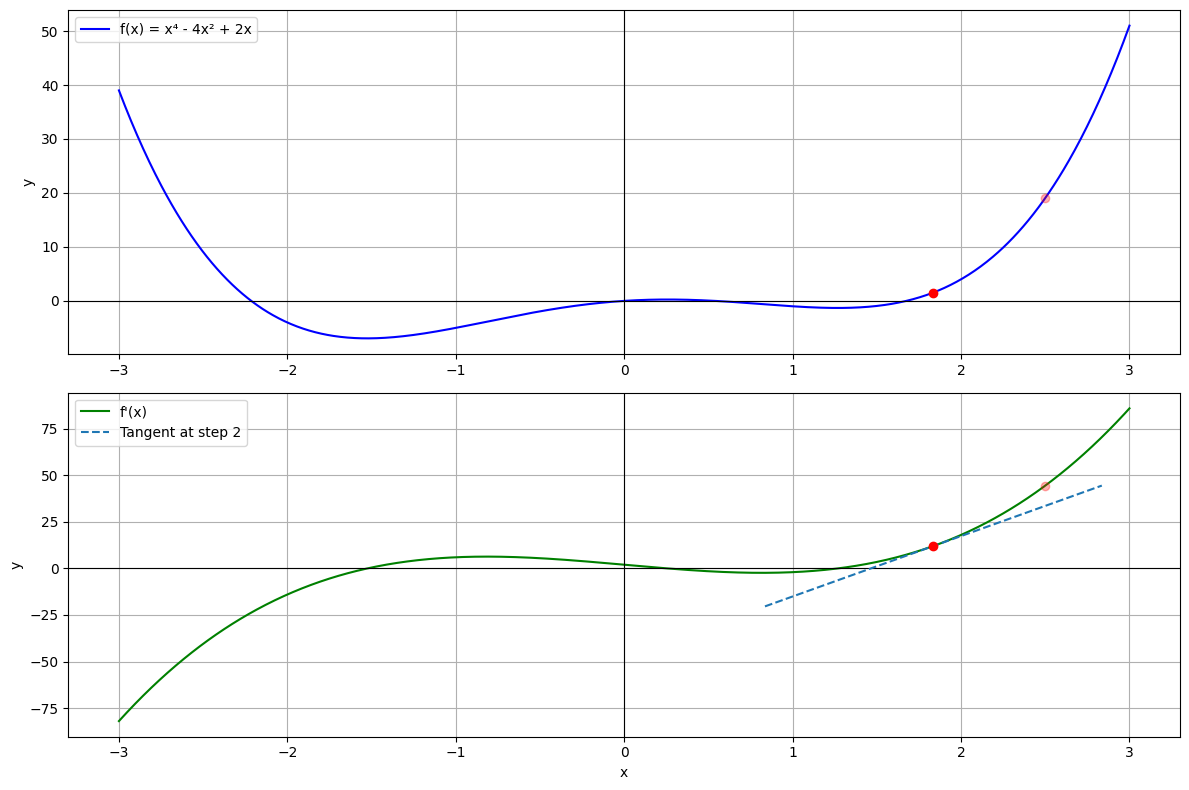

In [68]:
# Step 2
x_current = plot_newton_step_minima(x, y, x_current, step_history, f, 2)
step_history.append(x_current)

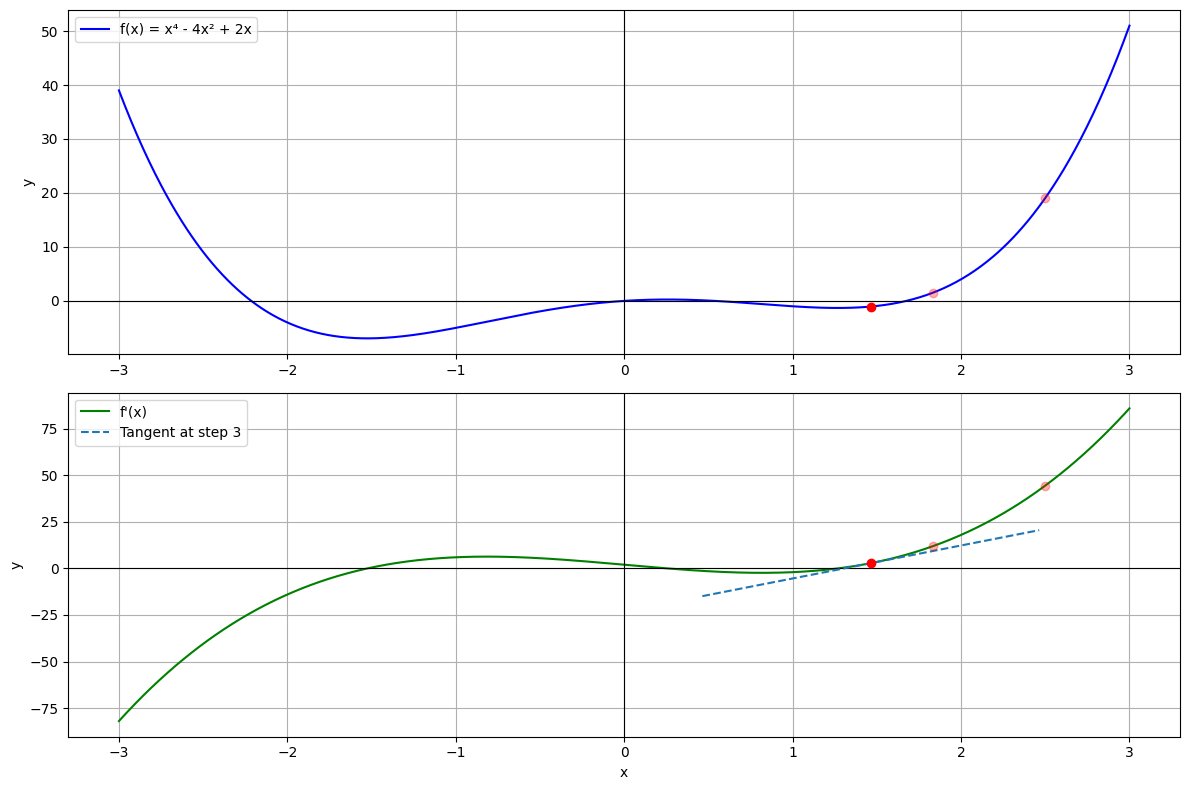

In [69]:
# Step 3
x_current = plot_newton_step_minima(x, y, x_current, step_history, f, 3)
step_history.append(x_current)

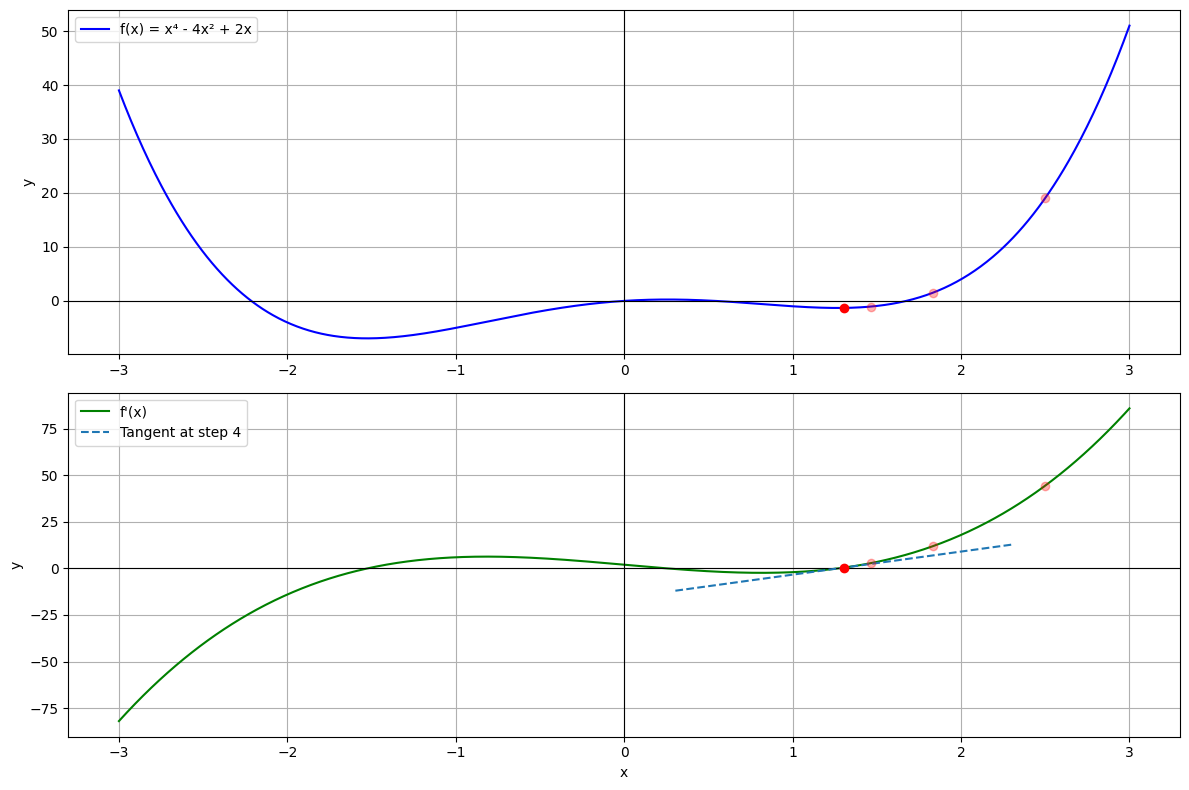

In [70]:
# Step 4
x_current = plot_newton_step_minima(x, y, x_current, step_history, f, 4)
step_history.append(x_current)

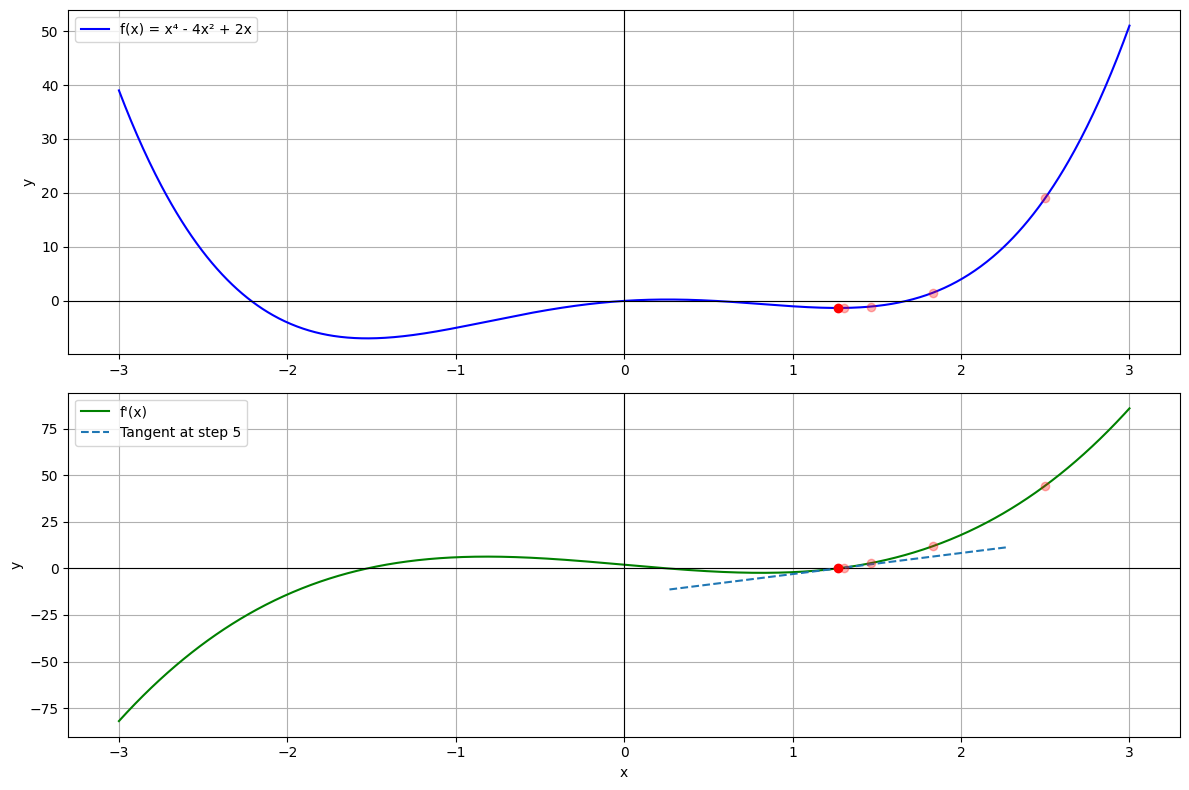

In [71]:
# Step 5
x_current = plot_newton_step_minima(x, y, x_current, step_history, f, 5)
step_history.append(x_current)

In [72]:
print("Convergence steps:")
for i, x in enumerate(step_history):
    print(
        f"Step {i}: x = {x:.10f}, f(x) = {f(x):.10f}, f'(x) = {numerical_derivative(f, x):.10f}"
    )

Convergence steps:
Step 0: x = 2.5000000000, f(x) = 19.0625000000, f'(x) = 44.5000000012
Step 1: x = 1.8358218309, f(x) = 1.5492062383, f'(x) = 12.0620792035
Step 2: x = 1.4640277382, f(x) = -1.0513874970, f'(x) = 2.8396328978
Step 3: x = 1.3037822625, f(x) = -1.3023443648, f'(x) = 0.4346695663
Step 4: x = 1.2687230825, f(x) = -1.3101871611, f'(x) = 0.0190576984
Step 5: x = 1.2670389301, f(x) = -1.3102032333, f'(x) = 0.0000431641


Questions:
- Can you overshoot the root using this method?
- 